# Lesson 11: applying PCBF to CCDC records

**Time-series dataset: Landsat surface-reflectance observations**

**Application: post-break spectral-persistence assessment**

The Persistence-Constrained Break Filter (PCBF) is an independent
postprocessor for standard CCDC records. CCDC is run first without changing
its detection process. PCBF then evaluates the fitted trajectory after each
confirmed candidate break and reclassifies candidates whose spectral change
does not persist beyond the selected duration threshold.

This lesson uses one real Landsat pixel time series as an API example. It is
not an accuracy assessment and does not prescribe one parameter setting for
all applications.

By the end of this lesson, you will be able to:

- run CCDC with `cold_detect` and inspect its confirmed candidate breaks;
- pass the unchanged CCDC record array to `cold_pcbf`;
- interpret retained and PCBF-removed candidates;
- compare the result with 32-day temporal compositing followed by CCDC;
- adjust the three public PCBF parameters; and
- visualize the original and processed break records in SWIR2 and NDVI.

## Workflow

1. Read and validate the Landsat time series.
2. Run CCDC.
3. Apply PCBF to the CCDC records.
4. Compare candidate status before and after PCBF.
5. Run CCDC on 32-day temporally composited observations.
6. Display the three SWIR2 time-series results.
7. Compare connected NDVI trajectories and their mapped break dates.
8. Explore adjustable PCBF parameters.

## Preparing the Landsat time series

The example dataset is stored in `tutorials/datasets/11_pcbf.csv`.
It contains the pixel longitude and latitude, acquisition date, and six
surface-reflectance bands. Reflectance is scaled by 10,000.

The tutorial CSV contains only the observations needed to run the example. It
does not contain prepared break labels or PCBF outputs.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

from pyxccd import cold_detect, cold_pcbf


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "legend.frameon": False,
    }
)


USER_DATA_PATH = None
EXAMPLE_DATA_FILENAME = "11_pcbf.csv"
EXAMPLE_DATA_URL = (
    "https://raw.githubusercontent.com/"
    "Remote-Sensing-of-Land-Resource-Lab/pyxccd/"
    "devel/tutorials/datasets/11_pcbf.csv"
)


def locate_example_data():
    if USER_DATA_PATH is not None:
        user_path = Path(USER_DATA_PATH).expanduser().resolve()

        if not user_path.exists():
            raise FileNotFoundError(f"User data file not found: {user_path}")

        return user_path

    search_roots = [Path.cwd(), *Path.cwd().parents]

    for root in search_roots:
        candidates = [
            root / "datasets" / EXAMPLE_DATA_FILENAME,
            root / "tutorials" / "datasets" / EXAMPLE_DATA_FILENAME,
        ]

        for candidate in candidates:
            if candidate.exists():
                return candidate.resolve()

    return EXAMPLE_DATA_URL


data_source = locate_example_data()
data = pd.read_csv(data_source)
data["date"] = pd.to_datetime(data["date"], errors="raise")
data["dates"] = data["date"].map(
    lambda value: value.to_pydatetime().date().toordinal()
)
data = data.sort_values("dates", kind="mergesort").reset_index(drop=True)

BANDS = ["blue", "green", "red", "nir", "swir1", "swir2"]

if data.empty or not data["dates"].is_monotonic_increasing:
    raise ValueError("The tutorial observations must be nonempty and date ordered.")

numeric_columns = ["longitude", "latitude", "dates", *BANDS]

if not np.isfinite(data[numeric_columns].to_numpy(dtype=float)).all():
    raise ValueError("The tutorial observations contain non-finite values.")

dates = data["dates"].to_numpy(dtype=np.int64)
blue, green, red, nir, swir1, swir2 = [
    np.rint(data[column].to_numpy(dtype=float)).astype(np.int64)
    for column in BANDS
]
thermal = np.zeros(len(data), dtype=np.int64)
qa = np.zeros(len(data), dtype=np.int64)

data[["longitude", "latitude", "date", *BANDS]].head()

,longitude,latitude,date,blue,green,red,nir,swir1,swir2
0,109.00679,37.25127,1995-01-06,931,1574,1944,2310,3228,3015
1,109.00679,37.25127,1995-01-31,983,1462,1837,2190,3029,2897
2,109.00679,37.25127,1995-02-16,1018,1524,1910,2208,3074,2941
3,109.00679,37.25127,1995-03-04,1062,1691,2149,2447,3251,3135
4,109.00679,37.25127,1995-03-11,1482,2099,2509,2711,3382,3189


## Running CCDC

PCBF does not replace or modify the CCDC detection call. First run the pyxccd
function `cold_detect` normally and retain its standard structured record
array. The parameters below are the CCDC settings used for this example.

In [2]:
ccdc_result = cold_detect(
    dates,
    blue,
    green,
    red,
    nir,
    swir1,
    swir2,
    thermal,
    qa,
    p_cg=0.99,
    conse=6,
    pos=1,
    gap_days=365.25,
    lam=20,
)

ccdc_result.dtype.names

('t_start',
 't_end',
 't_break',
 'pos',
 'num_obs',
 'category',
 'change_prob',
 'coefs',
 'rmse',
 'magnitude')

### Inspecting the original CCDC candidates

A confirmed CCDC candidate has a positive `t_break` and
`change_prob == 100`. Dates in CCDC records are Python ordinal dates.
The helper below creates a compact table without changing the records.

In [3]:
def ordinal_to_date(value):
    return pd.Timestamp.fromordinal(int(value))


def summarize_candidates(records, method):
    rows = []

    for index, record in enumerate(records):
        break_date = int(record["t_break"])

        if break_date <= 0:
            continue

        change_probability = int(record["change_prob"])
        rows.append(
            {
                "method": method,
                "record": index,
                "break_date": ordinal_to_date(break_date),
                "change_probability": change_probability,
                "status": (
                    "Retained"
                    if change_probability == 100
                    else "Not retained"
                ),
            }
        )

    return pd.DataFrame(rows)


ccdc_candidates = summarize_candidates(ccdc_result, "CCDC")
ccdc_candidates

,method,record,break_date,change_probability,status
0,CCDC,0,2001-08-19,100,Retained


## Applying PCBF

Pass the unchanged CCDC records to `cold_pcbf`. The following values are the
defaults used in this study, but all three are public parameters that users
may adjust for other applications:

- `duration_threshold_days`: maximum post-break duration evaluated for
  spectral recovery;
- `z_value`: multiplier applied to the band-specific pre-break model RMSE;
- `required_bands`: minimum number of Green, Red, NIR, SWIR1, and SWIR2 bands
  that must satisfy the recovery condition on the same date.

The existing minus-200 category rule remains fixed inside PCBF and is not a
public parameter.

In [4]:
pcbf_result = cold_pcbf(
    ccdc_result,
    duration_threshold_days=192,
    z_value=2.326,
    required_bands=4,
)

pcbf_candidates = summarize_candidates(pcbf_result, "CCDC+PCBF")
pd.concat(
    [ccdc_candidates, pcbf_candidates],
    ignore_index=True,
)

,method,record,break_date,change_probability,status
0,CCDC,0,2001-08-19,100,Retained
1,CCDC+PCBF,0,2001-08-19,0,Not retained


### Interpreting the PCBF result

`cold_pcbf` returns a copy with the same dtype, shape, order, and fitted model
fields as the input CCDC array. It does not refit CCDC and does not delete
candidate records. When PCBF removes a candidate, the returned record keeps
its original `t_break`, coefficients, RMSE, magnitude, and segment dates, but
its `change_prob` is set to `0`.

In [5]:
unchanged_fields = [
    field
    for field in ccdc_result.dtype.names
    if field != "change_prob"
    and np.array_equal(ccdc_result[field], pcbf_result[field])
]

comparison = pd.DataFrame(
    {
        "check": [
            "Input object is unchanged",
            "Returned dtype is unchanged",
            "Returned shape is unchanged",
            "Fields unchanged except change_prob",
            "Original confirmed breaks",
            "PCBF retained breaks",
        ],
        "value": [
            not np.shares_memory(ccdc_result, pcbf_result),
            ccdc_result.dtype == pcbf_result.dtype,
            ccdc_result.shape == pcbf_result.shape,
            len(unchanged_fields) == len(ccdc_result.dtype.names) - 1,
            int(np.count_nonzero(
                (ccdc_result["t_break"] > 0)
                & (ccdc_result["change_prob"] == 100)
            )),
            int(np.count_nonzero(
                (pcbf_result["t_break"] > 0)
                & (pcbf_result["change_prob"] == 100)
            )),
        ],
    }
)

comparison

,check,value
0,Input object is unchanged,True
1,Returned dtype is unchanged,True
2,Returned shape is unchanged,True
3,Fields unchanged except change_prob,True
4,Original confirmed breaks,1
5,PCBF retained breaks,0


## Comparing with 32-day temporal compositing

For context, the same observations are also reduced to one representative per
fixed 32-day window. Within each complete window, the observation with the
maximum NIR/Blue ratio is selected and CCDC is run on the resulting series.

This comparison is separate from PCBF: temporal compositing modifies the input
observations before CCDC, whereas PCBF evaluates the standard CCDC records
after detection.

In [6]:
WINDOW_DAYS = 32
SUPPORT_START = pd.Timestamp("1982-01-01").toordinal()
ANALYSIS_START = pd.Timestamp("1995-01-01").toordinal()
ANALYSIS_END = pd.Timestamp("2006-12-31").toordinal()

composite_candidates = data.copy()
composite_candidates["window_index"] = (
    (composite_candidates["dates"] - SUPPORT_START) // WINDOW_DAYS
).astype(int)
composite_candidates["selection_ratio"] = (
    composite_candidates["nir"] / composite_candidates["blue"]
)

selected_indices = []

for window_index, group in composite_candidates.groupby(
    "window_index",
    sort=True,
):
    window_start = SUPPORT_START + int(window_index) * WINDOW_DAYS
    window_end = window_start + WINDOW_DAYS - 1

    if window_start < ANALYSIS_START or window_end > ANALYSIS_END:
        continue

    eligible = group.loc[group["blue"] > 0].copy()

    if eligible.empty:
        continue

    selected_indices.append(
        int(
            eligible.sort_values(
                ["selection_ratio", "dates"],
                ascending=[False, True],
                kind="mergesort",
            ).index[0]
        )
    )

composited_data = composite_candidates.loc[selected_indices].sort_values(
    "dates",
    kind="mergesort",
).reset_index(drop=True)

composite_arrays = [
    np.rint(composited_data[column].to_numpy(dtype=float)).astype(np.int64)
    for column in BANDS
]
composite_thermal = np.zeros(len(composited_data), dtype=np.int64)
composite_qa = np.zeros(len(composited_data), dtype=np.int64)

composite_result = cold_detect(
    composited_data["dates"].to_numpy(dtype=np.int64),
    *composite_arrays,
    composite_thermal,
    composite_qa,
    p_cg=0.99,
    conse=6,
    pos=1,
    gap_days=365.25,
    lam=20,
)

method_comparison = pd.concat(
    [
        summarize_candidates(ccdc_result, "CCDC"),
        summarize_candidates(pcbf_result, "CCDC+PCBF"),
        summarize_candidates(composite_result, "Compositing+CCDC"),
    ],
    ignore_index=True,
)

pd.DataFrame(
    {
        "method": ["CCDC", "CCDC+PCBF", "Compositing+CCDC"],
        "input_observations": [len(data), len(data), len(composited_data)],
        "retained_breaks": [
            int(np.count_nonzero(
                (ccdc_result["t_break"] > 0)
                & (ccdc_result["change_prob"] == 100)
            )),
            int(np.count_nonzero(
                (pcbf_result["t_break"] > 0)
                & (pcbf_result["change_prob"] == 100)
            )),
            int(np.count_nonzero(
                (composite_result["t_break"] > 0)
                & (composite_result["change_prob"] == 100)
            )),
        ],
    }
).merge(
    method_comparison[["method", "break_date"]],
    on="method",
    how="left",
)

,method,input_observations,retained_breaks,break_date
0,CCDC,388,1,2001-08-19
1,CCDC+PCBF,388,0,2001-08-19
2,Compositing+CCDC,128,1,2003-03-01


## Displaying the three results

The first two panels show all valid SWIR2 observations and the same fitted CCDC
segments. The first panel displays the original confirmed CCDC break as a
solid red line. The second preserves the candidate date for auditing but uses
a dashed gray line because PCBF changed its `change_prob` to zero. The third
panel shows the observations selected by 32-day temporal compositing and the
CCDC fit obtained from that reduced series.

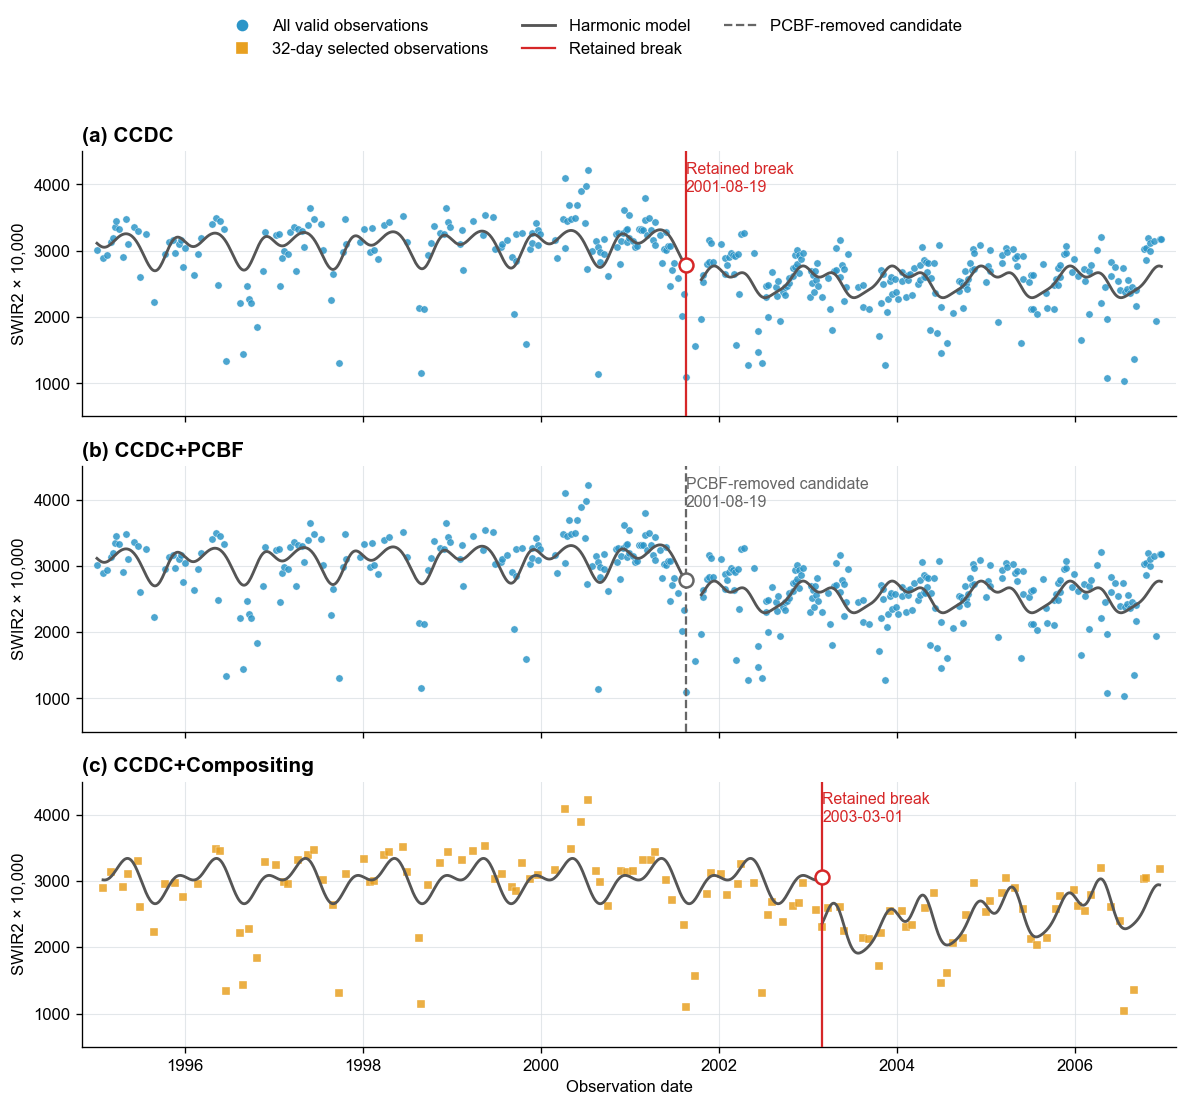

In [7]:
def fitted_values(record, ordinal, band_index=5):
    ordinal = np.asarray(ordinal, dtype=np.float64)
    phase = 2.0 * np.pi * ordinal / 365.25
    basis = np.vstack(
        [
            np.ones(ordinal.size),
            ordinal / 10000.0,
            np.cos(phase),
            np.sin(phase),
            np.cos(2.0 * phase),
            np.sin(2.0 * phase),
            np.cos(3.0 * phase),
            np.sin(3.0 * phase),
        ]
    )
    coefficients = np.asarray(record["coefs"][band_index], dtype=float)
    return coefficients @ basis


def plot_segments(ax, records, color="#555555"):
    for record in records:
        start = int(record["t_start"])
        end = int(record["t_end"])

        if start <= 0 or end < start:
            continue

        ordinal = np.arange(start, end + 1, 4, dtype=np.int64)

        if ordinal.size == 0 or ordinal[-1] != end:
            ordinal = np.append(ordinal, end)

        ax.plot(
            [ordinal_to_date(value) for value in ordinal],
            fitted_values(record, ordinal),
            color=color,
            linewidth=1.7,
            zorder=3,
        )


def plot_candidate_panel(
    ax,
    records,
    observations,
    title,
    point_color="#2B95C8",
    marker="o",
    point_size=19,
):
    observation_dates = [
        ordinal_to_date(value) for value in observations["dates"]
    ]
    ax.scatter(
        observation_dates,
        observations["swir2"],
        s=point_size,
        marker=marker,
        color=point_color,
        alpha=0.84,
        edgecolors="white",
        linewidths=0.25,
        zorder=2,
    )
    plot_segments(ax, records)

    for record in records:
        break_date = int(record["t_break"])

        if break_date <= 0:
            continue

        retained = int(record["change_prob"]) == 100
        color = "#D62728" if retained else "#666666"
        linestyle = "-" if retained else "--"
        label = "Retained break" if retained else "PCBF-removed candidate"
        break_timestamp = ordinal_to_date(break_date)
        break_value = float(
            fitted_values(record, np.array([break_date], dtype=np.int64))[0]
        )
        ax.axvline(
            break_timestamp,
            color=color,
            linestyle=linestyle,
            linewidth=1.35,
            zorder=4,
        )
        ax.scatter(
            [break_timestamp],
            [break_value],
            s=70,
            facecolors="white",
            edgecolors=color,
            linewidths=1.5,
            zorder=5,
        )
        ax.text(
            break_timestamp,
            0.96,
            f"{label}\n{break_timestamp:%Y-%m-%d}",
            transform=ax.get_xaxis_transform(),
            ha="left",
            va="top",
            fontsize=9.5,
            color=color,
        )

    ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold")
    ax.set_ylabel("SWIR2 × 10,000")
    ax.grid(color="#D9DEE3", linewidth=0.65, alpha=0.72)
    ax.spines[["top", "right"]].set_visible(False)


fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 9.2),
    dpi=120,
    sharex=True,
    sharey=True,
)

plot_candidate_panel(axes[0], ccdc_result, data, "(a) CCDC")
plot_candidate_panel(axes[1], pcbf_result, data, "(b) CCDC+PCBF")
plot_candidate_panel(
    axes[2],
    composite_result,
    composited_data,
    "(c) Compositing+CCDC",
    point_color="#E8A020",
    marker="s",
    point_size=27,
)

axes[2].set_xlabel("Observation date")
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_ylim(500, 4500)
axes[2].set_xlim(
    ordinal_to_date(int(dates.min()) - 60),
    ordinal_to_date(int(dates.max()) + 60),
)

legend = [
    Line2D([], [], marker="o", linestyle="none", color="#2B95C8", label="All valid observations"),
    Line2D([], [], marker="s", linestyle="none", color="#E8A020", label="32-day selected observations"),
    Line2D([], [], color="#555555", linewidth=1.7, label="Harmonic model"),
    Line2D([], [], color="#D62728", linewidth=1.35, label="Retained break"),
    Line2D([], [], color="#666666", linewidth=1.35, linestyle="--", label="PCBF-removed candidate"),
]

fig.legend(
    handles=legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.005),
    ncol=3,
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.91), h_pad=1.15)
plt.show()

## NDVI trajectories

NDVI is calculated directly from the observed Red and NIR reflectance as
`(NIR - Red) / (NIR + Red)`. Observations with NDVI below zero are excluded
from this display. The remaining observations are ordered by acquisition date
and connected to make their temporal trajectories easier to follow.

The vertical lines show the break dates returned by the multispectral CCDC
analysis above; they are not breaks independently estimated from NDVI. The
upper panel shows the full-observation candidate removed by PCBF, and the
lower panel shows the break retained after 32-day compositing and CCDC.

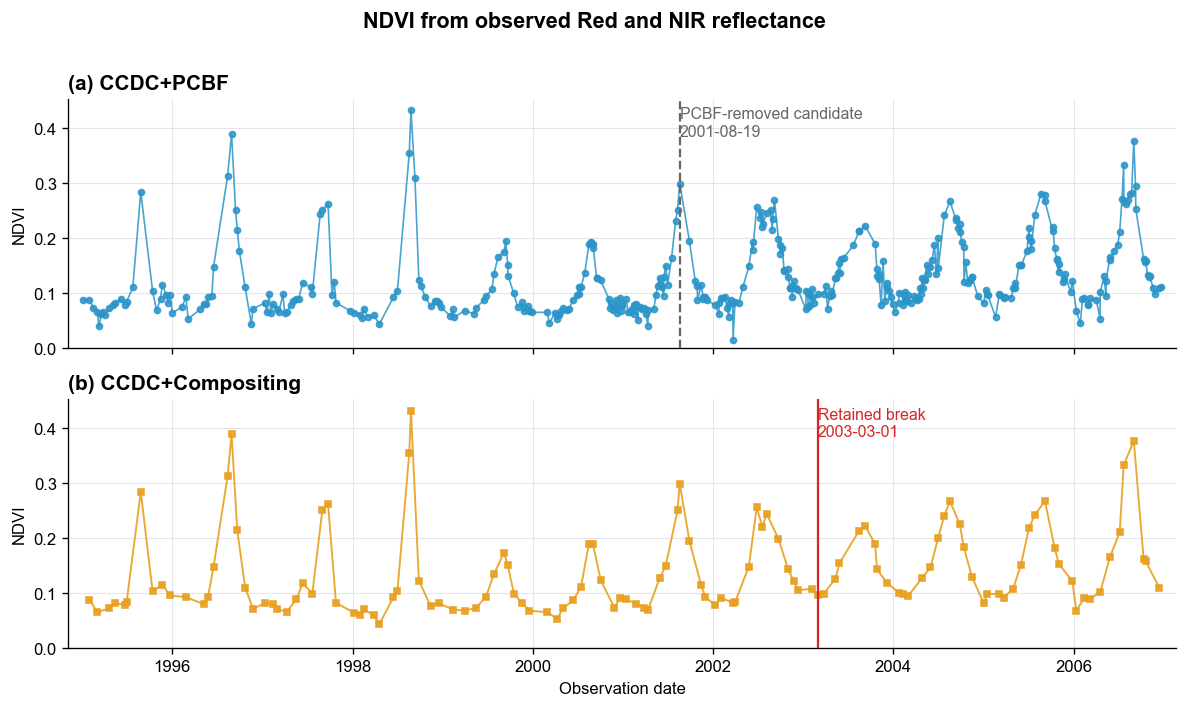

In [8]:
def calculate_observed_ndvi(observations):
    red_reflectance = observations["red"].to_numpy(dtype=float)
    nir_reflectance = observations["nir"].to_numpy(dtype=float)
    denominator = nir_reflectance + red_reflectance
    ndvi = np.divide(
        nir_reflectance - red_reflectance,
        denominator,
        out=np.full(denominator.shape, np.nan, dtype=float),
        where=denominator != 0,
    )
    valid_ndvi = np.isfinite(ndvi) & (ndvi >= 0)

    return pd.DataFrame(
        {
            "date": [
                ordinal_to_date(value)
                for value in observations.loc[valid_ndvi, "dates"]
            ],
            "ndvi": ndvi[valid_ndvi],
        }
    ).sort_values("date", kind="mergesort")


def add_ndvi_breaks(ax, records):
    label_row = 0

    for record in records:
        break_date = int(record["t_break"])

        if break_date <= 0:
            continue

        retained = int(record["change_prob"]) == 100
        color = "#D62728" if retained else "#666666"
        linestyle = "-" if retained else "--"
        label = "Retained break" if retained else "PCBF-removed candidate"
        break_timestamp = ordinal_to_date(break_date)

        ax.axvline(
            break_timestamp,
            color=color,
            linestyle=linestyle,
            linewidth=1.35,
            zorder=4,
        )
        ax.text(
            break_timestamp,
            0.97 - 0.13 * label_row,
            f"{label}\n{break_timestamp:%Y-%m-%d}",
            transform=ax.get_xaxis_transform(),
            ha="left",
            va="top",
            fontsize=9.5,
            color=color,
        )
        label_row += 1


full_ndvi = calculate_observed_ndvi(data)
composited_ndvi = calculate_observed_ndvi(composited_data)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 5.8),
    dpi=120,
    sharex=True,
    sharey=True,
)

axes[0].plot(
    full_ndvi["date"],
    full_ndvi["ndvi"],
    color="#2B95C8",
    marker="o",
    markersize=3.6,
    linewidth=1.0,
    alpha=0.86,
)
add_ndvi_breaks(axes[0], pcbf_result)
axes[0].set_title("(a) CCDC+PCBF", loc="left", fontsize=12.5, fontweight="bold")

axes[1].plot(
    composited_ndvi["date"],
    composited_ndvi["ndvi"],
    color="#E8A020",
    marker="s",
    markersize=4.0,
    linewidth=1.15,
    alpha=0.9,
)
add_ndvi_breaks(axes[1], composite_result)
axes[1].set_title(
    "(b) Compositing+CCDC",
    loc="left",
    fontsize=12.5,
    fontweight="bold",
)

for ax in axes:
    ax.set_ylabel("NDVI")
    ax.set_ylim(bottom=0)
    ax.grid(color="#D9DEE3", linewidth=0.65, alpha=0.72)

axes[1].set_xlabel("Observation date")
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].set_xlim(
    ordinal_to_date(int(dates.min()) - 60),
    ordinal_to_date(int(dates.max()) + 60),
)

fig.suptitle(
    "NDVI from observed Red and NIR reflectance",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
fig.tight_layout(h_pad=1.05)
plt.show()

## Adjusting the PCBF parameters

The values `192`, `2.326`, and `4` are defaults, not fixed constants. Users
can pass different values explicitly. The cell below first shows an editable
custom call and then varies only the duration threshold while holding the
other two settings constant.

The sensitivity table demonstrates API behavior for this single time series;
it is not a parameter-optimization result.

In [9]:
duration_threshold_days = 128
z_value = 2.326
required_bands = 4

custom_result = cold_pcbf(
    ccdc_result,
    duration_threshold_days=duration_threshold_days,
    z_value=z_value,
    required_bands=required_bands,
)

sensitivity_rows = []

for duration in [64, 96, 128, 192]:
    result = cold_pcbf(
        ccdc_result,
        duration_threshold_days=duration,
        z_value=2.326,
        required_bands=4,
    )
    retained_breaks = int(np.count_nonzero(
        (result["t_break"] > 0)
        & (result["change_prob"] == 100)
    ))
    sensitivity_rows.append(
        {
            "duration_threshold_days": duration,
            "z_value": 2.326,
            "required_bands": 4,
            "retained_breaks": retained_breaks,
            "candidate_status": (
                "Retained" if retained_breaks else "Removed by PCBF"
            ),
        }
    )

pd.DataFrame(sensitivity_rows)

,duration_threshold_days,z_value,required_bands,retained_breaks,candidate_status
0,64,2.326,4,1,Retained
1,96,2.326,4,0,Removed by PCBF
2,128,2.326,4,0,Removed by PCBF
3,192,2.326,4,0,Removed by PCBF


## Exercise

Change `exercise_duration_threshold_days`, `exercise_z_value`, or
`exercise_required_bands` below and compare the result with the default PCBF
output. Keep `required_bands` between 1 and 5 and use positive values for the
duration threshold and `z_value`.

In [10]:
exercise_duration_threshold_days = 96
exercise_z_value = 2.326
exercise_required_bands = 5

exercise_result = cold_pcbf(
    ccdc_result,
    duration_threshold_days=exercise_duration_threshold_days,
    z_value=exercise_z_value,
    required_bands=exercise_required_bands,
)

summarize_candidates(exercise_result, "Exercise result")

,method,record,break_date,change_probability,status
0,Exercise result,0,2001-08-19,100,Retained


## Common pitfalls

- Do not add a `pcbf=True` argument to `cold_detect`; PCBF is a separate call.
- Pass the standard one-dimensional CCDC structured record array to
  `cold_pcbf`. If `cold_detect(output_cm=True)` is used, pass only the first
  returned CCDC-record element.
- A PCBF-removed candidate is not deleted. Select final retained breaks with
  both `t_break > 0` and `change_prob == 100`.
- PCBF does not refit CCDC. The fitted segment coefficients and candidate date
  remain available for auditing.
- Treat the three defaults as method settings that may require sensitivity
  assessment for a new application, not as immutable constants.

## Summary

This lesson demonstrated the standalone PCBF workflow:

1. Read and validate a Landsat time series.
2. Run CCDC once with `cold_detect`.
3. Pass the resulting CCDC records to `cold_pcbf`.
4. Interpret retained and removed candidates through `change_prob` while
   preserving `t_break` and the fitted model fields.
5. Visualize the candidate before and after PCBF.
6. Compare the full-observation results with 32-day temporal compositing.
7. Compare the nonnegative observed NDVI trajectories and mapped break dates.
8. Adjust the public duration, prediction-band, and band-count parameters
   explicitly when needed.